# Structural Instability in Big Five South African Banking Equities

This notebook reproduces the empirical analysis for Paper 1. 

**Data note:** the IRESS dataset is proprietary and is not uploaded to GitHub.

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis, jarque_bera, ks_2samp, levene

warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except ImportError:
    display = print

In [5]:
file_path = "IRESS DATASET.xlsx"

base_dir = r"C:\Users\komet\OneDrive\Documents\PhD Statistics\P1_Outputs"
project_dir = os.path.join(base_dir, "Paper1_Structural_Instability_Journal")

fig_dir = os.path.join(project_dir, "figures")
table_dir = os.path.join(project_dir, "tables")
data_dir = os.path.join(project_dir, "processed_data")
result_dir = os.path.join(project_dir, "results")

for folder in [project_dir, fig_dir, table_dir, data_dir, result_dir]:
    os.makedirs(folder, exist_ok=True)

print("Project folder:")
print(project_dir)

Project folder:
C:\Users\komet\OneDrive\Documents\PhD Statistics\P1_Outputs\Paper1_Structural_Instability_Journal


In [7]:
bank_column_map = {
    "STANDARD BANK GROUP LTD": "StandardBank",
    "FIRSTRAND LTD": "FirstRand",
    "ABSA GROUP LTD": "Absa",
    "NEDBANK GROUP LTD": "Nedbank",
    "CAPITEC BANK HOLDINGS LTD": "Capitec"
}

banks = list(bank_column_map.values())

print("\nBanks included in the study:")
print(banks)


Banks included in the study:
['StandardBank', 'FirstRand', 'Absa', 'Nedbank', 'Capitec']


In [9]:
def format_pvalue(p):
    if pd.isna(p):
        return np.nan
    if p < 0.0001:
        return "< 0.0001"
    return round(float(p), 4)


def save_plot(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, filename), dpi=300, bbox_inches="tight")
    plt.show()


def save_table(df, filename):
    path = os.path.join(result_dir, filename)
    df.to_excel(path, index=False)
    return path


def safe_break_string(break_dates):
    if len(break_dates) == 0:
        return ""
    return ", ".join([pd.to_datetime(d).strftime("%Y-%m-%d") for d in break_dates])

In [11]:
df_raw = pd.read_excel(file_path)

df_raw["Date"] = pd.to_datetime(df_raw["Date"])
df_raw = df_raw.sort_values("Date").reset_index(drop=True)

df_raw = df_raw.rename(columns=bank_column_map)

df = df_raw[["Date"] + banks].copy()

for bank in banks:
    df[bank] = pd.to_numeric(df[bank], errors="coerce")

print("\nDataset preview:")
display(df.head())

print("\nDataset information:")
print(df.info())

print("\nDate range:")
print(df["Date"].min().strftime("%Y-%m-%d"), "to", df["Date"].max().strftime("%Y-%m-%d"))

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate dates:")
print(df["Date"].duplicated().sum())


Dataset preview:


,Date,StandardBank,FirstRand,Absa,Nedbank,Capitec
0,2016-01-27,10380,4050,13144,17500,43995
1,2016-01-28,10700,4219,13700,18300,45300
2,2016-01-29,11221,4472,14396,18744,48100
3,2016-02-01,11084,4449,14250,18548,46897
4,2016-02-02,10480,4190,13681,17900,45388



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          2496 non-null   datetime64[ns]
 1   StandardBank  2496 non-null   int64         
 2   FirstRand     2496 non-null   int64         
 3   Absa          2496 non-null   int64         
 4   Nedbank       2496 non-null   int64         
 5   Capitec       2496 non-null   int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 117.1 KB
None

Date range:
2016-01-27 to 2026-01-23

Missing values:
Date            0
StandardBank    0
FirstRand       0
Absa            0
Nedbank         0
Capitec         0
dtype: int64

Duplicate dates:
0


In [13]:
prices = df.set_index("Date")

prices.to_csv(os.path.join(data_dir, "IRESS_cleaned_bank_prices.csv"))

print("\nCleaned price data:")
display(prices.head())


Cleaned price data:


,StandardBank,FirstRand,Absa,Nedbank,Capitec
Date,,,,,
2016-01-27,10380,4050,13144,17500,43995
2016-01-28,10700,4219,13700,18300,45300
2016-01-29,11221,4472,14396,18744,48100
2016-02-01,11084,4449,14250,18548,46897
2016-02-02,10480,4190,13681,17900,45388


In [15]:
returns = 100 * np.log(prices / prices.shift(1))
returns = returns.dropna()

abs_returns = returns.abs()
squared_returns = returns ** 2

returns.to_csv(os.path.join(data_dir, "IRESS_bank_log_returns.csv"))
abs_returns.to_csv(os.path.join(data_dir, "IRESS_bank_absolute_returns.csv"))
squared_returns.to_csv(os.path.join(data_dir, "IRESS_bank_squared_returns.csv"))

print("\nReturn data:")
print(returns.shape)
display(returns.head())


Return data:
(2495, 5)


,StandardBank,FirstRand,Absa,Nedbank,Capitec
Date,,,,,
2016-01-28,3.036286,4.088125,4.143045,4.470018,2.923104
2016-01-29,4.754328,5.823760,4.955456,2.397264,5.997514
2016-02-01,-1.228440,-0.515638,-1.019348,-1.051173,-2.532847
2016-02-02,-5.603395,-5.997862,-4.074890,-3.556125,-3.270595
2016-02-03,-0.286670,-0.047744,0.495809,0.239935,0.026435


In [17]:
summary_rows = []

for bank in banks:
    x = returns[bank].dropna()
    jb = jarque_bera(x)

    summary_rows.append({
        "Bank": bank,
        "Observations": len(x),
        "Mean": x.mean(),
        "Standard deviation": x.std(),
        "Minimum": x.min(),
        "Maximum": x.max(),
        "Skewness": skew(x),
        "Excess kurtosis": kurtosis(x, fisher=True),
        "Jarque-Bera statistic": jb.statistic,
        "Jarque-Bera p-value": jb.pvalue,
        "Jarque-Bera p-value formatted": format_pvalue(jb.pvalue)
    })

summary_table = pd.DataFrame(summary_rows)

round_cols = [
    "Mean", "Standard deviation", "Minimum", "Maximum",
    "Skewness", "Excess kurtosis", "Jarque-Bera statistic",
    "Jarque-Bera p-value"
]

summary_table[round_cols] = summary_table[round_cols].round(4)

print("\nDescriptive statistics:")
display(summary_table)

save_table(summary_table, "Table_1_descriptive_statistics.xlsx")


Descriptive statistics:


,Bank,Observations,Mean,Standard deviation,Minimum,Maximum,Skewness,Excess kurtosis,Jarque-Bera statistic,Jarque-Bera p-value,Jarque-Bera p-value formatted
0,StandardBank,2495,0.0420,1.9773,-13.6465,11.7015,-0.1859,4.4253,2050.2174,0.0,< 0.0001
1,FirstRand,2495,0.0326,1.9935,-15.4073,12.9060,-0.1440,4.6438,2250.4370,0.0,< 0.0001
2,Absa,2495,0.0257,2.1512,-16.8912,16.9603,-0.2034,6.7564,4762.7383,0.0,< 0.0001
3,Nedbank,2495,0.0179,2.1546,-17.1716,12.8139,-0.3156,7.5401,5951.8285,0.0,< 0.0001
4,Capitec,2495,0.0919,2.1589,-32.7413,35.1771,-0.1791,54.9393,313793.0190,0.0,< 0.0001


'C:\\Users\\komet\\OneDrive\\Documents\\PhD Statistics\\P1_Outputs\\Paper1_Structural_Instability_Journal\\results\\Table_1_descriptive_statistics.xlsx'

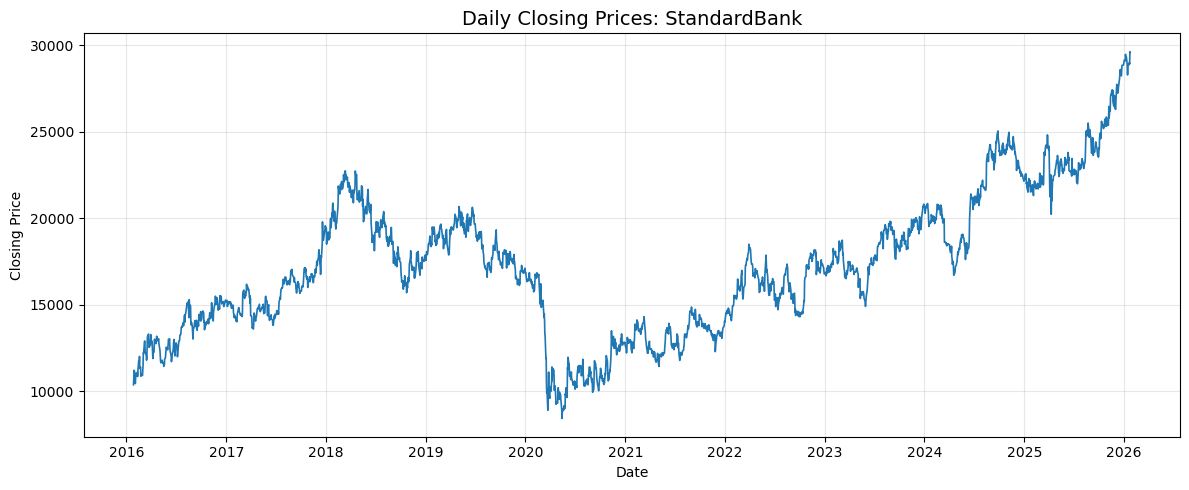

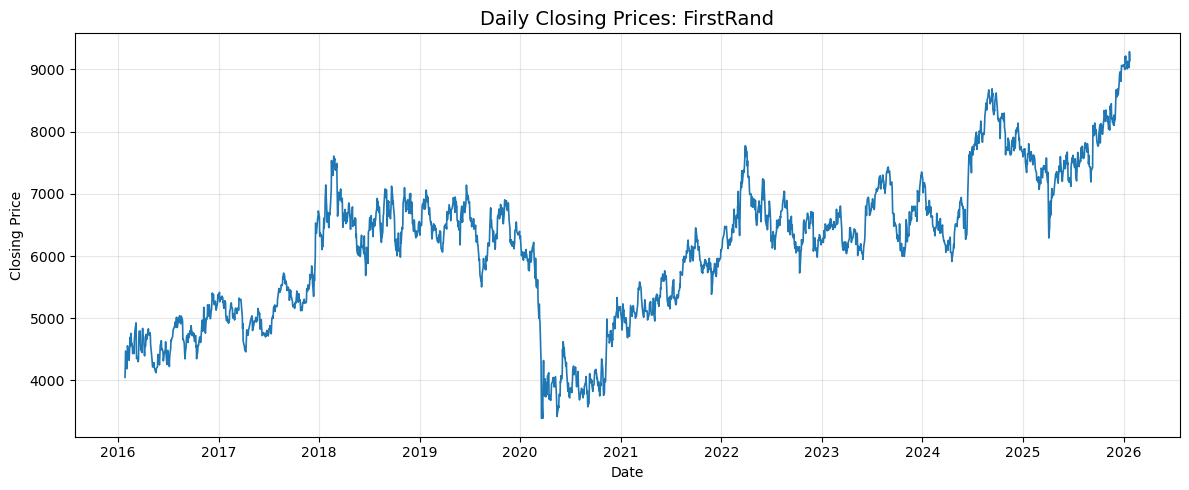

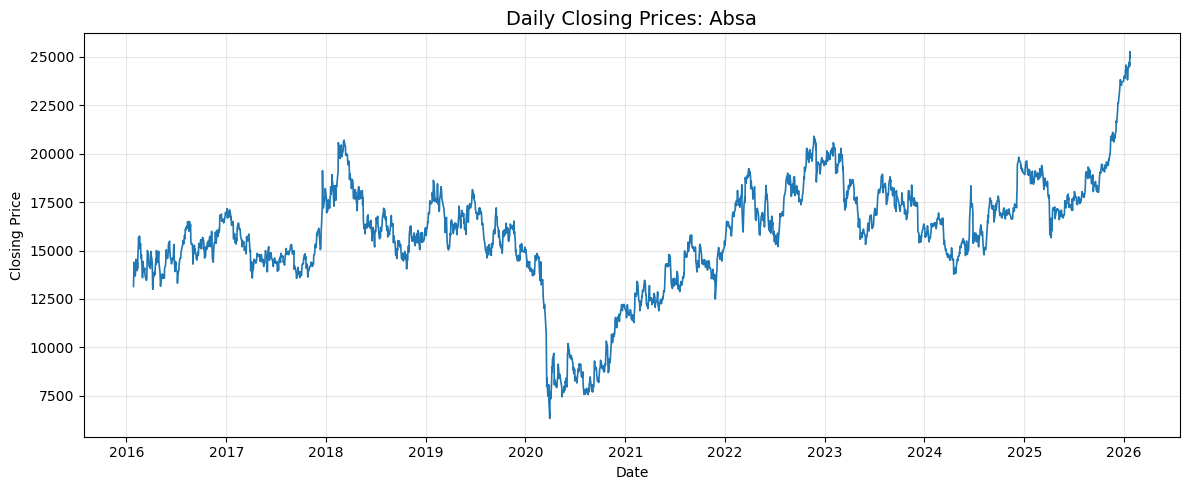

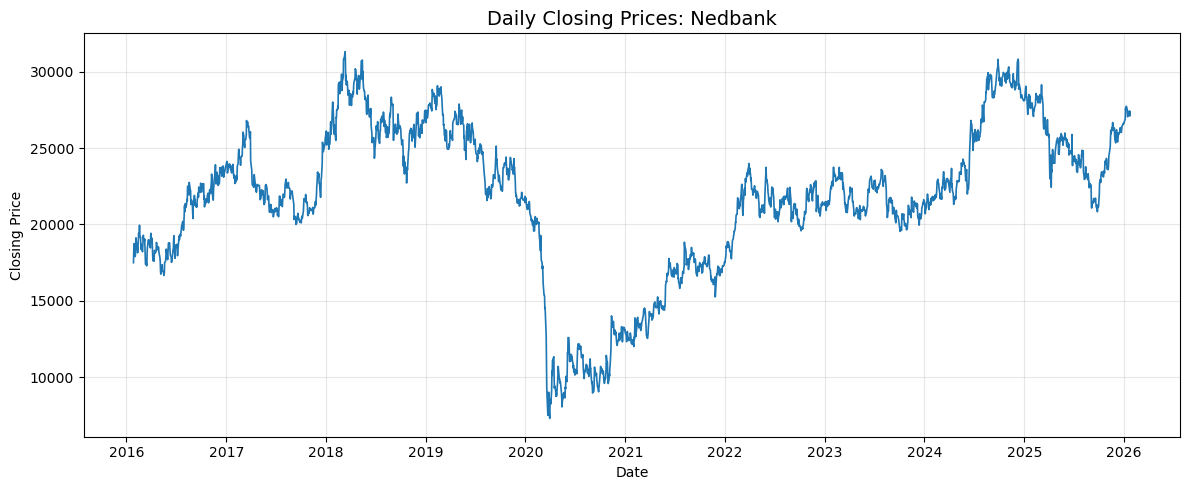

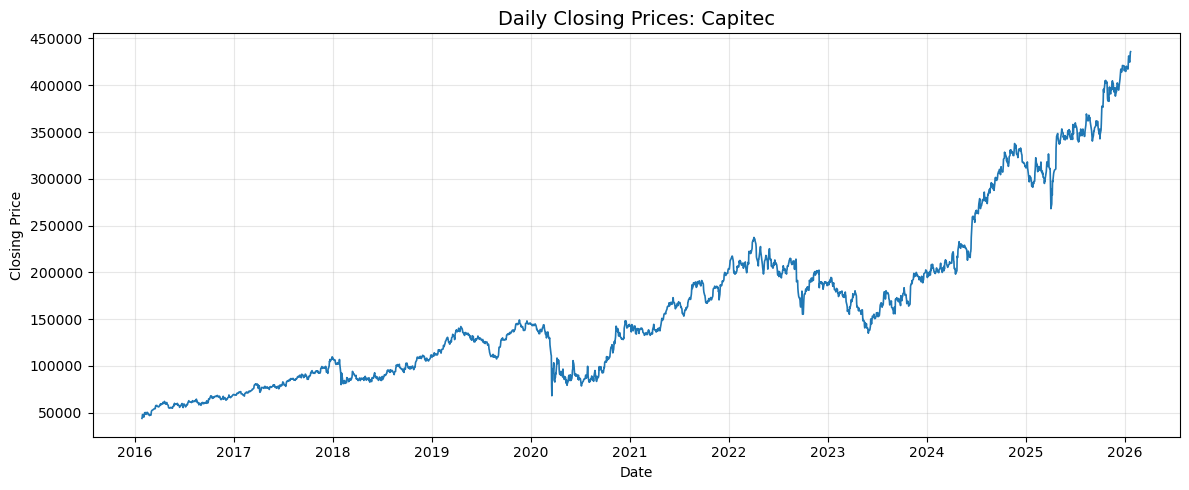

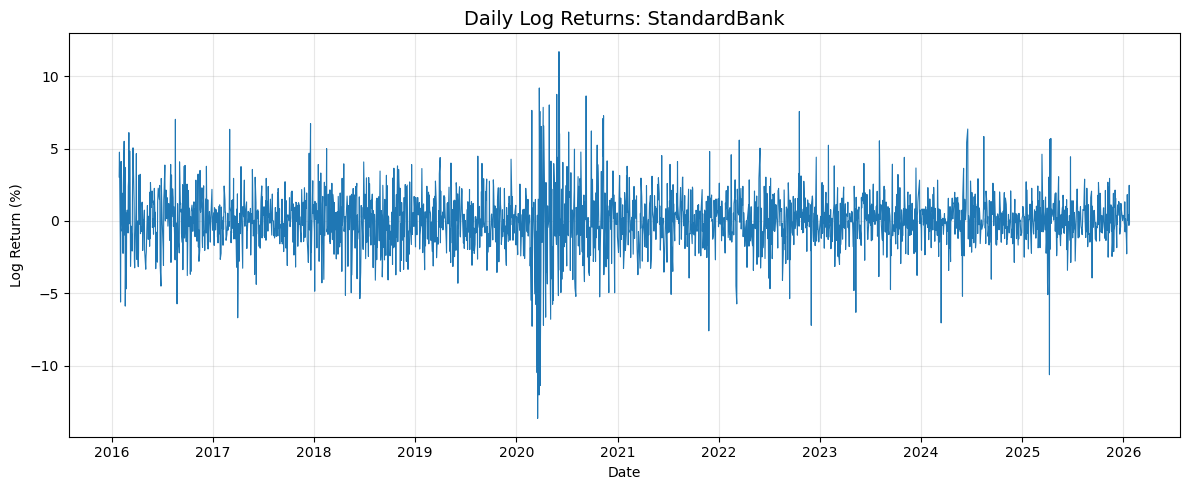

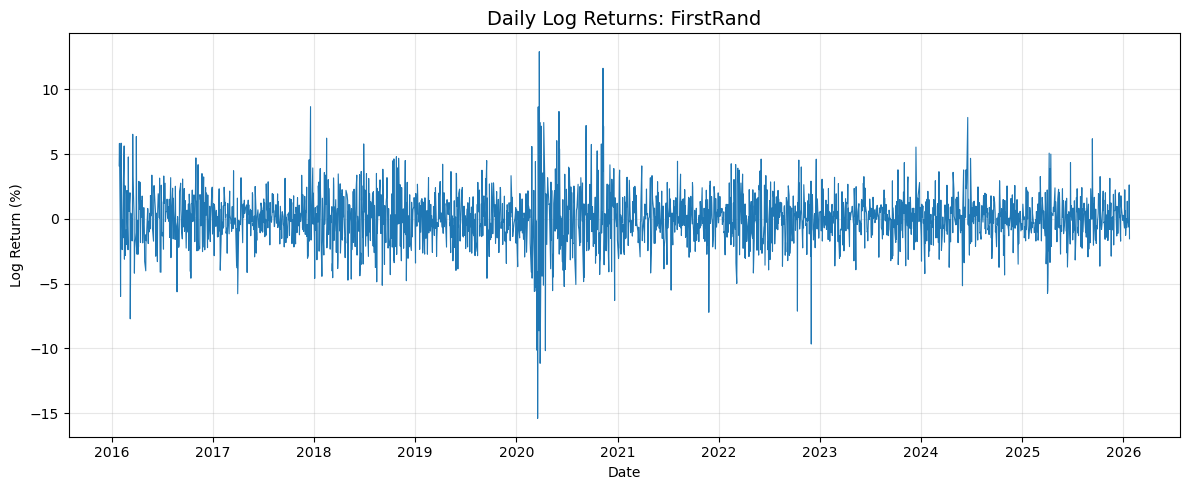

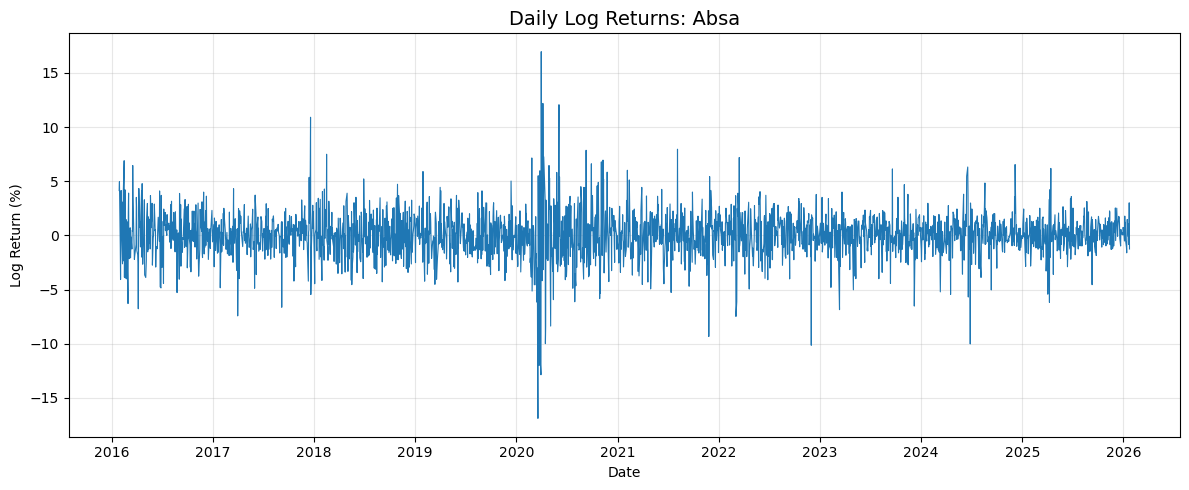

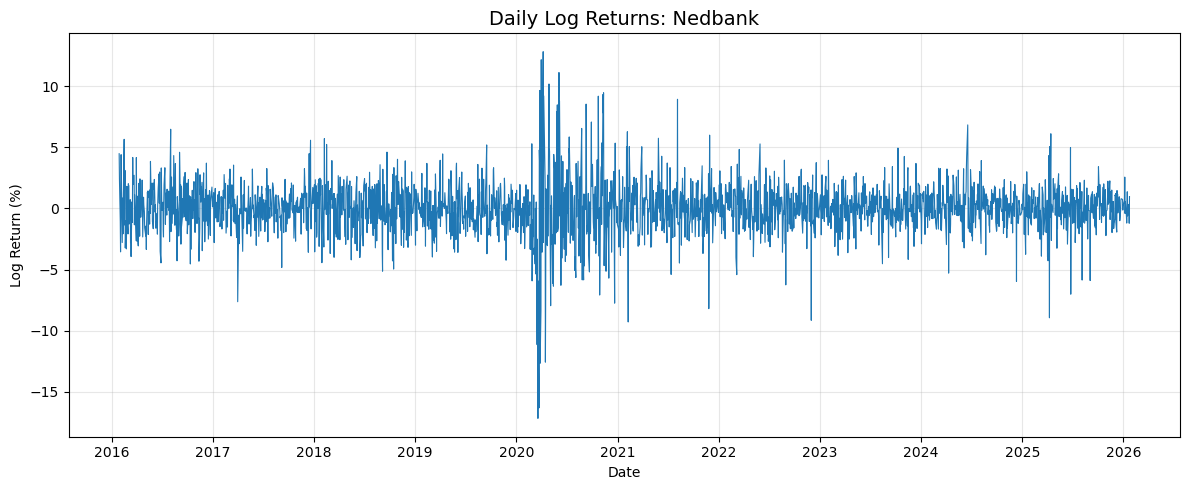

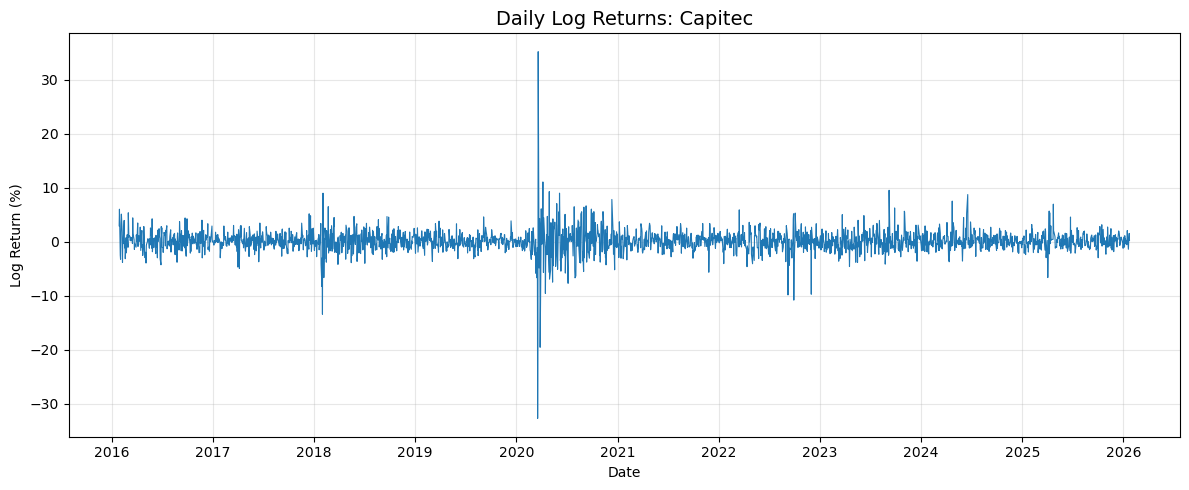

In [27]:
for bank in banks:
    plt.figure(figsize=(12, 5))
    plt.plot(prices.index, prices[bank], linewidth=1.2)

    plt.title(f"Daily Closing Prices: {bank}", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    save_plot(f"Figure_1_price_{bank.replace(' ', '_')}.png")
    plt.close()

for bank in banks:
    plt.figure(figsize=(12, 5))
    plt.plot(returns.index, returns[bank], linewidth=0.8)

    plt.title(f"Daily Log Returns: {bank}", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Log Return (%)")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    save_plot(f"Figure_2_log_returns_{bank.replace(' ', '_')}.png")
    plt.close()

In [29]:
def compute_sse_matrix(y, min_size):
    n = len(y)
    y = np.asarray(y)

    csum = np.concatenate([[0], np.cumsum(y)])
    csum2 = np.concatenate([[0], np.cumsum(y ** 2)])

    sse = np.full((n, n), np.inf)

    for start in range(n):
        min_end = start + min_size

        if min_end > n:
            continue

        ends = np.arange(min_end, n + 1)

        seg_sum = csum[ends] - csum[start]
        seg_sum2 = csum2[ends] - csum2[start]
        seg_len = ends - start

        vals = seg_sum2 - (seg_sum ** 2) / seg_len
        sse[start, ends - 1] = vals

    return sse


def multiple_break_detection(series, max_breaks=5, min_size=120):
    y_series = series.dropna()
    y = y_series.values
    dates = y_series.index
    n = len(y)

    sse = compute_sse_matrix(y, min_size)

    all_models = []

    for m in range(max_breaks + 1):
        segments = m + 1

        dp = np.full((segments, n), np.inf)
        prev = np.full((segments, n), -1, dtype=int)

        for end in range(min_size - 1, n):
            dp[0, end] = sse[0, end]

        for k in range(1, segments):
            for end in range((k + 1) * min_size - 1, n):
                best_value = np.inf
                best_split = -1

                split_start = k * min_size - 1
                split_end = end - min_size

                for split in range(split_start, split_end + 1):
                    value = dp[k - 1, split] + sse[split + 1, end]

                    if value < best_value:
                        best_value = value
                        best_split = split

                dp[k, end] = best_value
                prev[k, end] = best_split

        total_sse = dp[segments - 1, n - 1]

        if not np.isfinite(total_sse) or total_sse <= 0:
            continue

        parameters = segments + m
        bic = n * np.log(total_sse / n) + parameters * np.log(n)

        break_indices = []
        k = segments - 1
        end = n - 1

        while k > 0:
            split = prev[k, end]
            break_indices.append(split + 1)
            end = split
            k -= 1

        break_indices = sorted(break_indices)
        break_dates = [dates[i] for i in break_indices]

        all_models.append({
            "Number of breaks": m,
            "SSE": total_sse,
            "BIC": bic,
            "Break indices": break_indices,
            "Break dates": break_dates
        })

    if len(all_models) == 0:
        return {
            "Number of breaks": 0,
            "SSE": np.nan,
            "BIC": np.nan,
            "Break indices": [],
            "Break dates": []
        }, []

    best_model = min(all_models, key=lambda x: x["BIC"])

    return best_model, all_models


def run_break_detection(dataset, series_label, max_breaks=5, min_size=120):
    selected_rows = []
    bic_rows = []

    for bank in banks:
        print(f"Running break detection for {bank}: {series_label}")

        best_model, all_models = multiple_break_detection(
            dataset[bank],
            max_breaks=max_breaks,
            min_size=min_size
        )

        selected_rows.append({
            "Bank": bank,
            "Series": series_label,
            "Selected number of breaks": best_model["Number of breaks"],
            "Selected BIC": best_model["BIC"],
            "Break dates": safe_break_string(best_model["Break dates"])
        })

        for model in all_models:
            bic_rows.append({
                "Bank": bank,
                "Series": series_label,
                "Number of breaks": model["Number of breaks"],
                "SSE": model["SSE"],
                "BIC": model["BIC"],
                "Break dates": safe_break_string(model["Break dates"])
            })

    selected_table = pd.DataFrame(selected_rows)
    bic_table = pd.DataFrame(bic_rows)

    if not selected_table.empty:
        selected_table["Selected BIC"] = selected_table["Selected BIC"].round(4)

    if not bic_table.empty:
        bic_table[["SSE", "BIC"]] = bic_table[["SSE", "BIC"]].round(4)

    return selected_table, bic_table

In [31]:
abs_breaks_table, abs_bic_table = run_break_detection(
    abs_returns,
    series_label="Absolute returns",
    max_breaks=5,
    min_size=120
)

sq_breaks_table, sq_bic_table = run_break_detection(
    squared_returns,
    series_label="Squared returns",
    max_breaks=5,
    min_size=120
)

print("\nAbsolute-return structural breaks:")
display(abs_breaks_table)

print("\nSquared-return structural breaks:")
display(sq_breaks_table)

save_table(abs_breaks_table, "Table_2_absolute_return_structural_breaks.xlsx")
save_table(sq_breaks_table, "Table_3_squared_return_structural_breaks.xlsx")
save_table(abs_bic_table, "Appendix_absolute_return_BIC_comparison.xlsx")
save_table(sq_bic_table, "Appendix_squared_return_BIC_comparison.xlsx")

Running break detection for StandardBank: Absolute returns
Running break detection for FirstRand: Absolute returns
Running break detection for Absa: Absolute returns
Running break detection for Nedbank: Absolute returns
Running break detection for Capitec: Absolute returns
Running break detection for StandardBank: Squared returns
Running break detection for FirstRand: Squared returns
Running break detection for Absa: Squared returns
Running break detection for Nedbank: Squared returns
Running break detection for Capitec: Squared returns

Absolute-return structural breaks:


,Bank,Series,Selected number of breaks,Selected BIC,Break dates
0,StandardBank,Absolute returns,3,1370.2139,"2016-10-03, 2020-02-20, 2020-12-01"
1,FirstRand,Absolute returns,5,1408.3867,"2016-12-19, 2017-12-08, 2018-11-14, 2020-02-21..."
2,Absa,Absolute returns,4,1852.2596,"2016-07-22, 2020-02-26, 2020-11-12, 2022-07-22"
3,Nedbank,Absolute returns,3,1793.2125,"2020-02-26, 2020-11-12, 2021-08-25"
4,Capitec,Absolute returns,4,2318.7357,"2017-12-05, 2018-07-05, 2020-03-12, 2020-09-14"



Squared-return structural breaks:


,Bank,Series,Selected number of breaks,Selected BIC,Break dates
0,StandardBank,Squared returns,3,11161.8257,"2020-02-20, 2020-08-14, 2021-02-08"
1,FirstRand,Squared returns,2,11423.7592,"2020-02-24, 2020-11-16"
2,Absa,Squared returns,2,12834.3119,"2020-03-16, 2020-09-11"
3,Nedbank,Squared returns,3,12900.1191,"2020-03-16, 2020-09-11, 2021-03-04"
4,Capitec,Squared returns,2,17670.9195,"2020-03-12, 2020-09-04"


'C:\\Users\\komet\\OneDrive\\Documents\\PhD Statistics\\P1_Outputs\\Paper1_Structural_Instability_Journal\\results\\Appendix_squared_return_BIC_comparison.xlsx'

In [33]:
mean_breaks_table, mean_bic_table = run_break_detection(
    returns,
    series_label="Mean returns",
    max_breaks=5,
    min_size=120
)

print("\nMean-return break check:")
display(mean_breaks_table)

save_table(mean_breaks_table, "Appendix_mean_return_break_check.xlsx")
save_table(mean_bic_table, "Appendix_mean_return_BIC_comparison.xlsx")

Running break detection for StandardBank: Mean returns
Running break detection for FirstRand: Mean returns
Running break detection for Absa: Mean returns
Running break detection for Nedbank: Mean returns
Running break detection for Capitec: Mean returns

Mean-return break check:


,Bank,Series,Selected number of breaks,Selected BIC,Break dates
0,StandardBank,Mean returns,0,3408.7410,
1,FirstRand,Mean returns,0,3449.3108,
2,Absa,Mean returns,0,3829.3499,
3,Nedbank,Mean returns,0,3837.2775,
4,Capitec,Mean returns,0,3847.0271,


'C:\\Users\\komet\\OneDrive\\Documents\\PhD Statistics\\P1_Outputs\\Paper1_Structural_Instability_Journal\\results\\Appendix_mean_return_BIC_comparison.xlsx'

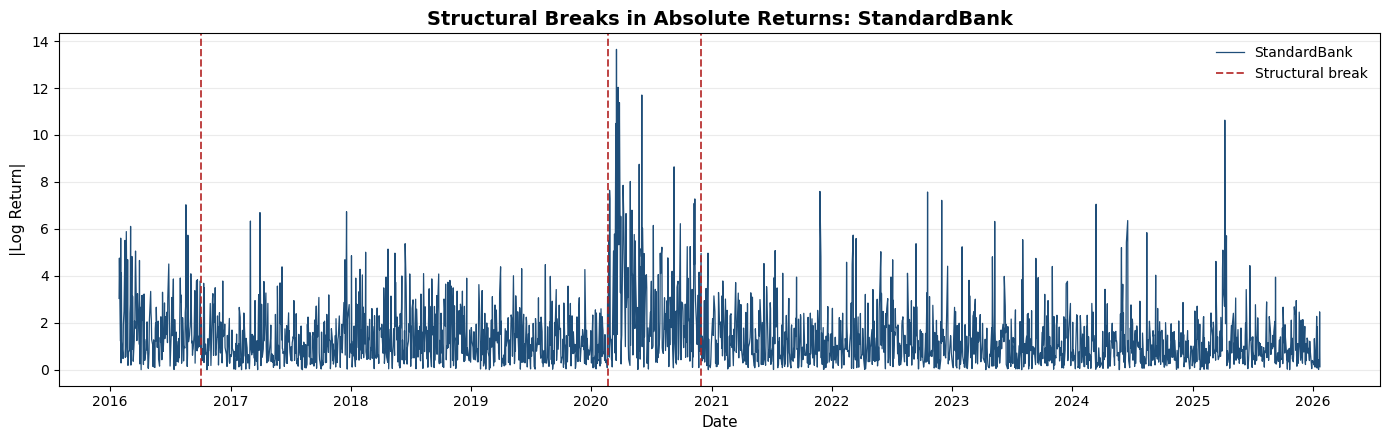

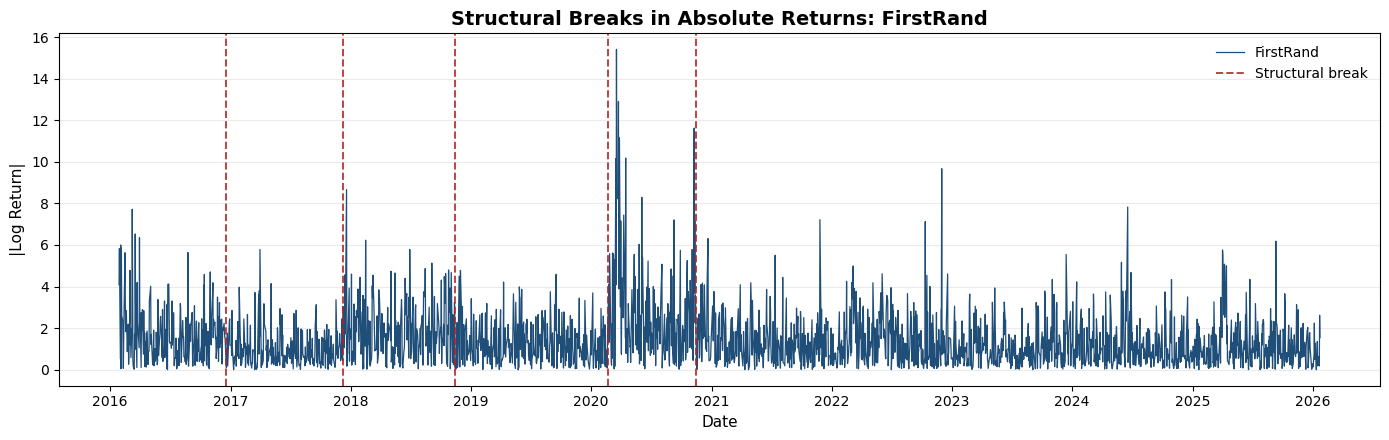

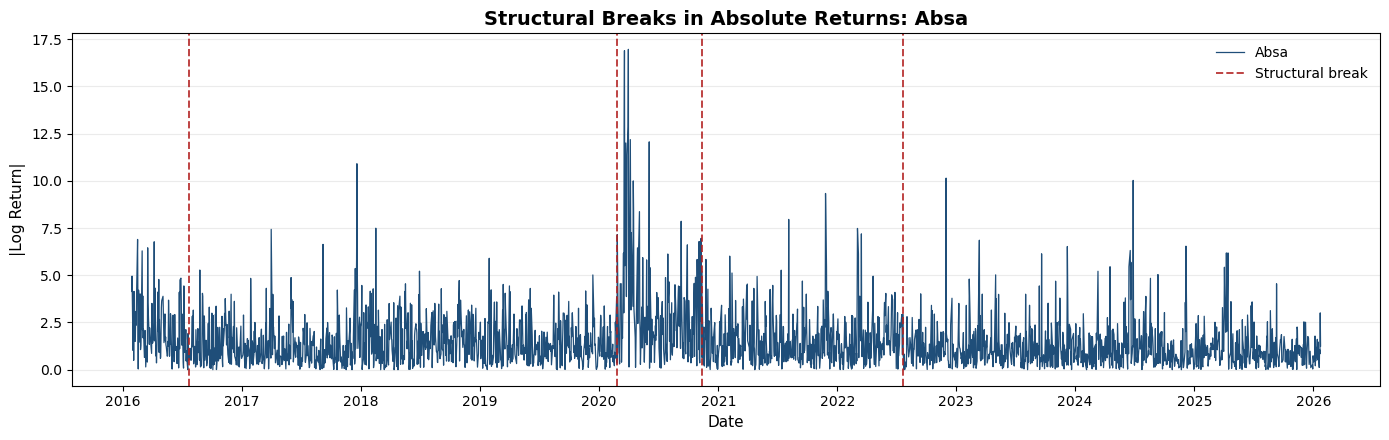

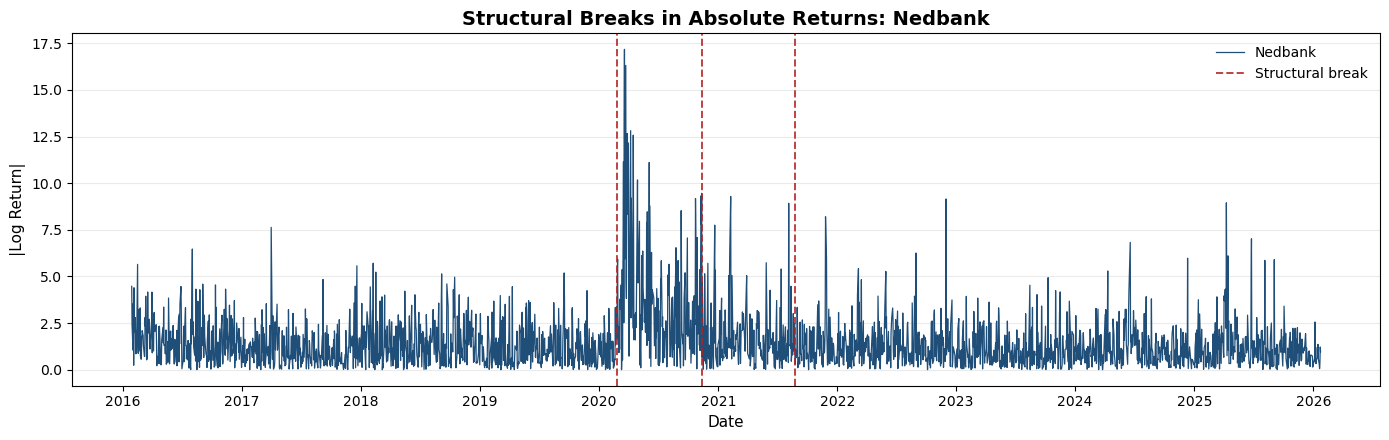

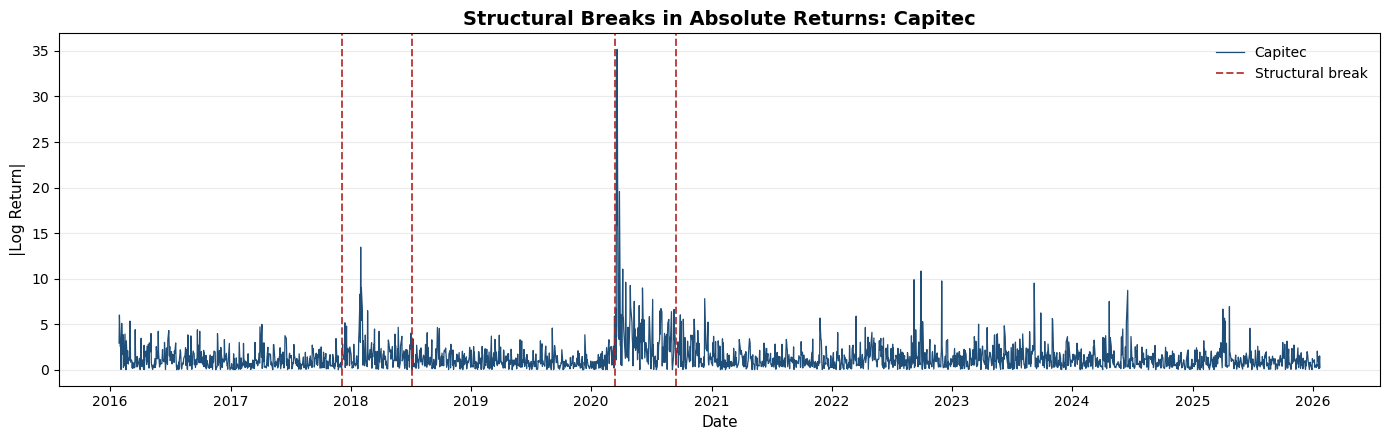

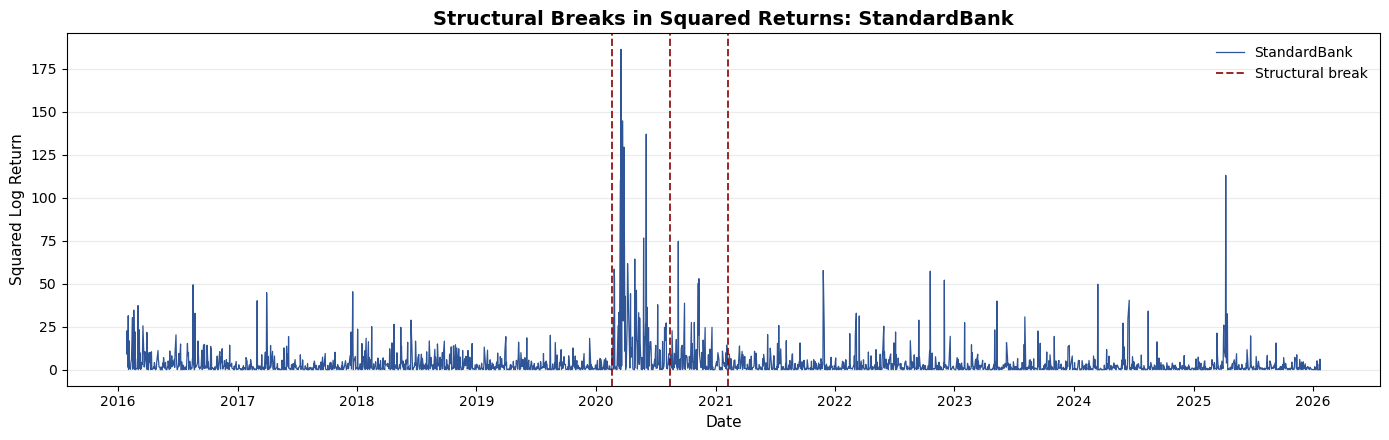

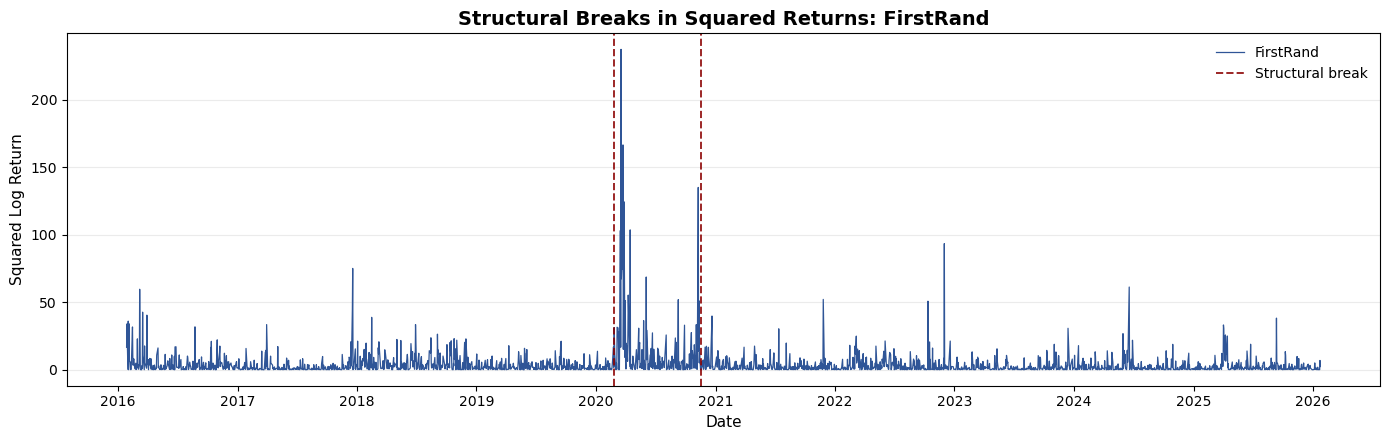

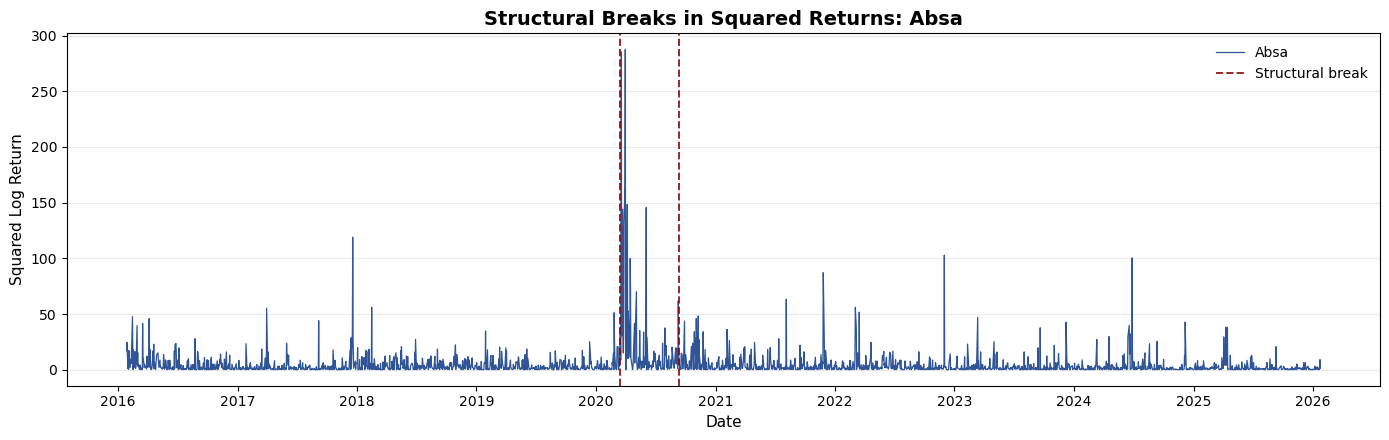

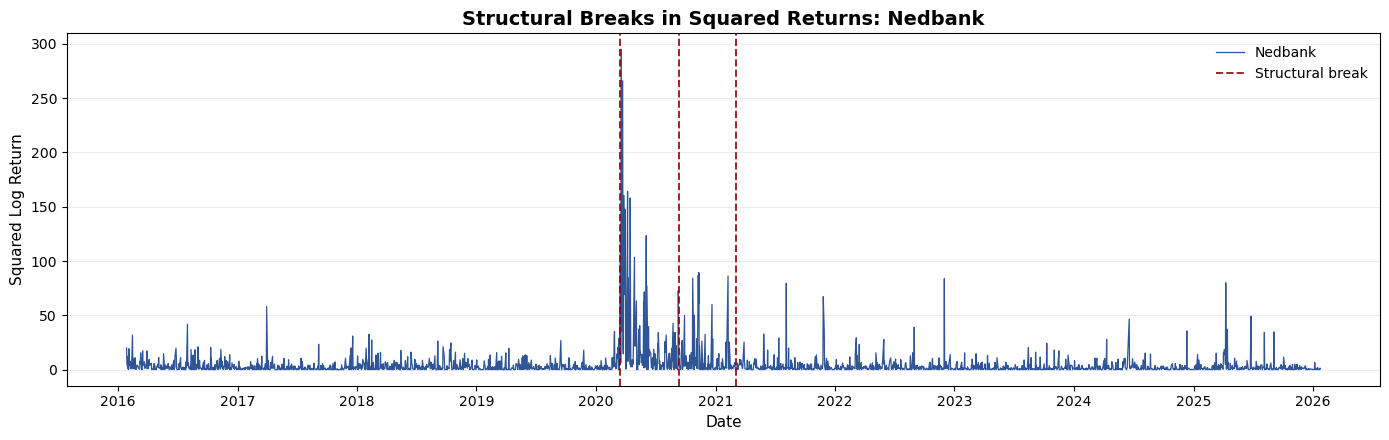

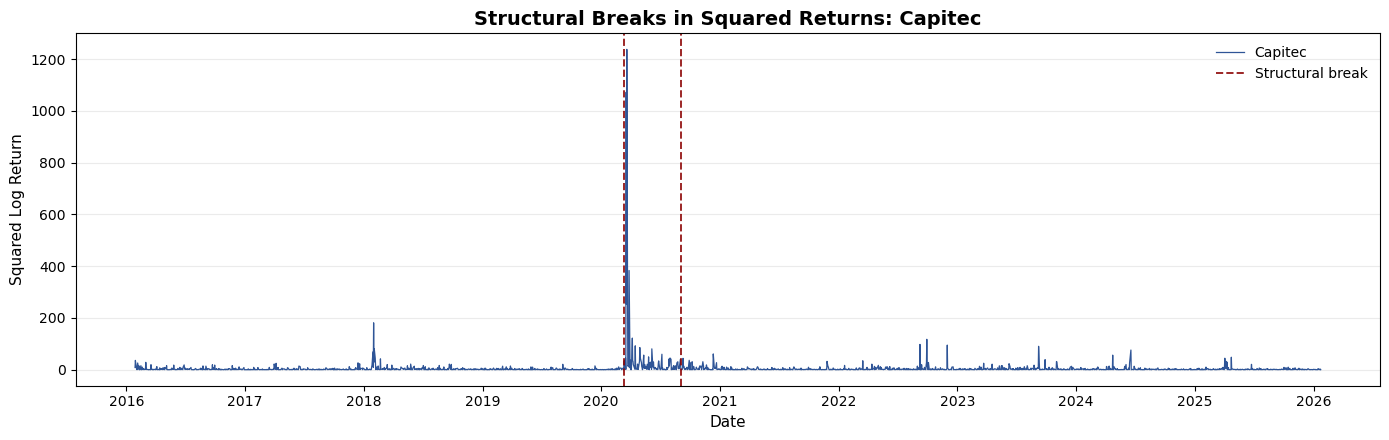

In [35]:
def extract_break_dates_from_table(break_table, bank):
    row = break_table[break_table["Bank"] == bank].iloc[0]
    break_string = row["Break dates"]

    if pd.isna(break_string) or break_string == "":
        return []

    return [pd.to_datetime(x.strip()) for x in break_string.split(",")]


def plot_breaks_for_each_bank(
    dataset,
    break_table,
    title_prefix,
    ylabel,
    filename_prefix,
    line_color="#1f4e79",
    break_color="#b22222"
):
    for bank in banks:
        break_dates = extract_break_dates_from_table(break_table, bank)

        plt.figure(figsize=(14, 4.5))

        plt.plot(
            dataset.index,
            dataset[bank],
            color=line_color,
            linewidth=0.9,
            label=bank
        )

        for i, bd in enumerate(break_dates):
            plt.axvline(
                bd,
                color=break_color,
                linestyle="--",
                linewidth=1.4,
                alpha=0.85,
                label="Structural break" if i == 0 else None
            )

        plt.title(f"{title_prefix}: {bank}", fontsize=14, fontweight="bold")
        plt.xlabel("Date", fontsize=11)
        plt.ylabel(ylabel, fontsize=11)
        plt.grid(axis="y", alpha=0.25)
        plt.legend(frameon=False, fontsize=10, loc="upper right")

        plt.tight_layout()
        plt.savefig(
            os.path.join(fig_dir, f"{filename_prefix}_{bank}.png"),
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()


plot_breaks_for_each_bank(
    abs_returns,
    abs_breaks_table,
    "Structural Breaks in Absolute Returns",
    "|Log Return|",
    "absolute_return_breaks",
    line_color="#1f4e79",
    break_color="#b22222"
)

plot_breaks_for_each_bank(
    squared_returns,
    sq_breaks_table,
    "Structural Breaks in Squared Returns",
    "Squared Log Return",
    "squared_return_breaks",
    line_color="#2f5597",
    break_color="#8b0000"
)

In [37]:
def icss_breaks(series, critical_value=1.358, cluster_window=20):
    y = series.dropna()
    x = y.values
    dates = y.index
    n = len(x)

    centered = x - np.mean(x)
    squares = centered ** 2
    cumulative = np.cumsum(squares)
    total = cumulative[-1]

    if total == 0:
        return []

    D = cumulative / total - np.arange(1, n + 1) / n
    statistic = np.sqrt(n / 2) * np.abs(D)

    candidates = np.where(statistic > critical_value)[0]

    if len(candidates) == 0:
        return []

    groups = []
    current = [candidates[0]]

    for idx in candidates[1:]:
        if idx - current[-1] <= cluster_window:
            current.append(idx)
        else:
            groups.append(current)
            current = [idx]

    groups.append(current)

    break_indices = []

    for group in groups:
        best_idx = group[np.argmax(statistic[group])]
        break_indices.append(best_idx)

    break_dates = [dates[i] for i in break_indices]

    return break_dates

icss_rows = []

for bank in banks:
    break_dates = icss_breaks(returns[bank])

    icss_rows.append({
        "Bank": bank,
        "Number of ICSS variance breaks": len(break_dates),
        "ICSS break dates": safe_break_string(break_dates)
    })

icss_table = pd.DataFrame(icss_rows)

print("\nICSS variance break robustness results:")
display(icss_table)

save_table(icss_table, "Table_4_ICSS_variance_breaks.xlsx")


ICSS variance break robustness results:


,Bank,Number of ICSS variance breaks,ICSS break dates
0,StandardBank,2,"2020-12-21, 2025-04-14"
1,FirstRand,1,2021-01-11
2,Absa,1,2020-11-30
3,Nedbank,2,"2021-02-12, 2025-04-14"
4,Capitec,1,2020-12-21


'C:\\Users\\komet\\OneDrive\\Documents\\PhD Statistics\\P1_Outputs\\Paper1_Structural_Instability_Journal\\results\\Table_4_ICSS_variance_breaks.xlsx'

In [39]:
def create_regime_intervals(index, break_dates):
    if len(break_dates) == 0:
        return [(index.min(), index.max())]

    sorted_breaks = sorted(break_dates)
    dates = [index.min()] + sorted_breaks + [index.max()]

    intervals = []

    for i in range(len(dates) - 1):
        intervals.append((dates[i], dates[i + 1]))

    return intervals


def regime_validation_tests(return_series, break_dates, source_series_label):
   
    intervals = create_regime_intervals(return_series.index, break_dates)

    rows = []

    for i in range(len(intervals) - 1):
        start_1, end_1 = intervals[i]
        start_2, end_2 = intervals[i + 1]

        if i == 0:
            data1 = return_series[
                (return_series.index >= start_1) &
                (return_series.index <= end_1)
            ]
        else:
            data1 = return_series[
                (return_series.index > start_1) &
                (return_series.index <= end_1)
            ]

        data2 = return_series[
            (return_series.index > start_2) &
            (return_series.index <= end_2)
        ]

        if len(data1) < 20 or len(data2) < 20:
            continue

        ks_stat, ks_p = ks_2samp(data1, data2)
        bf_stat, bf_p = levene(data1, data2, center="median")

        rows.append({
            "Break source": source_series_label,
            "Comparison": f"Regime {i + 1} vs Regime {i + 2}",
            "Regime 1 start": start_1.strftime("%Y-%m-%d"),
            "Regime 1 end": end_1.strftime("%Y-%m-%d"),
            "Regime 2 start": start_2.strftime("%Y-%m-%d"),
            "Regime 2 end": end_2.strftime("%Y-%m-%d"),
            "KS statistic": ks_stat,
            "KS p-value": ks_p,
            "KS p-value formatted": format_pvalue(ks_p),
            "KS decision": "Different distributions" if ks_p < 0.05 else "No significant distributional difference",
            "Brown-Forsythe statistic": bf_stat,
            "Brown-Forsythe p-value": bf_p,
            "Brown-Forsythe p-value formatted": format_pvalue(bf_p),
            "Brown-Forsythe decision": "Different variances" if bf_p < 0.05 else "No significant variance difference"
        })

    return pd.DataFrame(rows)

validation_tables = []

for bank in banks:
    abs_break_dates = extract_break_dates_from_table(abs_breaks_table, bank)

    temp_abs = regime_validation_tests(
        return_series=returns[bank],
        break_dates=abs_break_dates,
        source_series_label="Absolute-return breaks"
    )

    if not temp_abs.empty:
        temp_abs.insert(0, "Bank", bank)
        validation_tables.append(temp_abs)

    sq_break_dates = extract_break_dates_from_table(sq_breaks_table, bank)

    temp_sq = regime_validation_tests(
        return_series=returns[bank],
        break_dates=sq_break_dates,
        source_series_label="Squared-return breaks"
    )

    if not temp_sq.empty:
        temp_sq.insert(0, "Bank", bank)
        validation_tables.append(temp_sq)


if len(validation_tables) > 0:
    regime_validation_table = pd.concat(validation_tables, ignore_index=True)
else:
    regime_validation_table = pd.DataFrame()

if not regime_validation_table.empty:
    numeric_validation_cols = [
        "KS statistic", "KS p-value",
        "Brown-Forsythe statistic", "Brown-Forsythe p-value"
    ]

    regime_validation_table[numeric_validation_cols] = (
        regime_validation_table[numeric_validation_cols].round(4)
    )

print("\nFull regime validation test results:")
display(regime_validation_table)

save_table(regime_validation_table, "Appendix_full_regime_validation_tests.xlsx")


Full regime validation test results:


,Bank,Break source,Comparison,Regime 1 start,Regime 1 end,Regime 2 start,Regime 2 end,KS statistic,KS p-value,KS p-value formatted,KS decision,Brown-Forsythe statistic,Brown-Forsythe p-value,Brown-Forsythe p-value formatted,Brown-Forsythe decision
0,StandardBank,Absolute-return breaks,Regime 1 vs Regime 2,2016-01-28,2016-10-03,2016-10-03,2020-02-20,0.1067,0.0734,0.0734,No significant distributional difference,26.9758,0.0000,< 0.0001,Different variances
1,StandardBank,Absolute-return breaks,Regime 2 vs Regime 3,2016-10-03,2020-02-20,2020-02-20,2020-12-01,0.1781,0.0001,< 0.0001,Different distributions,177.5728,0.0000,< 0.0001,Different variances
2,StandardBank,Absolute-return breaks,Regime 3 vs Regime 4,2020-02-20,2020-12-01,2020-12-01,2026-01-23,0.2154,0.0000,< 0.0001,Different distributions,243.9342,0.0000,< 0.0001,Different variances
3,StandardBank,Squared-return breaks,Regime 1 vs Regime 2,2016-01-28,2020-02-20,2020-02-20,2020-08-14,0.2091,0.0001,0.0001,Different distributions,167.3339,0.0000,< 0.0001,Different variances
4,StandardBank,Squared-return breaks,Regime 2 vs Regime 3,2020-02-20,2020-08-14,2020-08-14,2021-02-08,0.1678,0.0565,0.0565,No significant distributional difference,14.7754,0.0002,0.0002,Different variances
5,StandardBank,Squared-return breaks,Regime 3 vs Regime 4,2020-08-14,2021-02-08,2021-02-08,2026-01-23,0.1626,0.0049,0.0049,Different distributions,59.1882,0.0000,< 0.0001,Different variances
6,FirstRand,Absolute-return breaks,Regime 1 vs Regime 2,2016-01-28,2016-12-19,2016-12-19,2017-12-08,0.1448,0.0131,0.0131,Different distributions,37.0058,0.0000,< 0.0001,Different variances
7,FirstRand,Absolute-return breaks,Regime 2 vs Regime 3,2016-12-19,2017-12-08,2017-12-08,2018-11-14,0.1821,0.0006,0.0006,Different distributions,62.6415,0.0000,< 0.0001,Different variances
8,FirstRand,Absolute-return breaks,Regime 3 vs Regime 4,2017-12-08,2018-11-14,2018-11-14,2020-02-21,0.1300,0.0192,0.0192,Different distributions,36.0579,0.0000,< 0.0001,Different variances
9,FirstRand,Absolute-return breaks,Regime 4 vs Regime 5,2018-11-14,2020-02-21,2020-02-21,2020-11-16,0.1833,0.0007,0.0007,Different distributions,85.6894,0.0000,< 0.0001,Different variances


'C:\\Users\\komet\\OneDrive\\Documents\\PhD Statistics\\P1_Outputs\\Paper1_Structural_Instability_Journal\\results\\Appendix_full_regime_validation_tests.xlsx'

In [41]:
validation_summary_rows = []

for bank in banks:
    if regime_validation_table.empty:
        bank_tests = pd.DataFrame()
    else:
        bank_tests = regime_validation_table[
            regime_validation_table["Bank"] == bank
        ]

    if bank_tests.empty:
        ks_count = 0
        bf_count = 0
        total_count = 0
    else:
        ks_count = bank_tests[
            bank_tests["KS decision"] == "Different distributions"
        ].shape[0]

        bf_count = bank_tests[
            bank_tests["Brown-Forsythe decision"] == "Different variances"
        ].shape[0]

        total_count = bank_tests[
            (bank_tests["KS decision"] == "Different distributions") |
            (bank_tests["Brown-Forsythe decision"] == "Different variances")
        ].shape[0]

    validation_summary_rows.append({
        "Bank": bank,
        "Significant distributional differences": ks_count,
        "Significant variance differences": bf_count,
        "Total significant adjacent-regime differences": total_count
    })

validation_summary_table = pd.DataFrame(validation_summary_rows)

print("\nCompact regime validation summary:")
display(validation_summary_table)

save_table(validation_summary_table, "Table_5_regime_validation_summary.xlsx")


Compact regime validation summary:


,Bank,Significant distributional differences,Significant variance differences,Total significant adjacent-regime differences
0,StandardBank,4,6,6
1,FirstRand,7,7,7
2,Absa,5,6,6
3,Nedbank,6,6,6
4,Capitec,6,6,6


'C:\\Users\\komet\\OneDrive\\Documents\\PhD Statistics\\P1_Outputs\\Paper1_Structural_Instability_Journal\\results\\Table_5_regime_validation_summary.xlsx'

In [43]:
def break_table_to_long_format(break_table, break_type):
    rows = []

    for _, row in break_table.iterrows():
        bank = row["Bank"]
        break_string = row["Break dates"]

        if pd.isna(break_string) or break_string == "":
            continue

        break_dates = [pd.to_datetime(x.strip()) for x in break_string.split(",")]

        for bd in break_dates:
            rows.append({
                "Bank": bank,
                "Break type": break_type,
                "Break date": bd,
                "Break month": bd.to_period("M").strftime("%Y-%m"),
                "Break year": bd.year
            })

    return pd.DataFrame(rows)


all_break_dates = pd.concat(
    [
        break_table_to_long_format(abs_breaks_table, "Absolute-return break"),
        break_table_to_long_format(sq_breaks_table, "Squared-return break")
    ],
    ignore_index=True
)

if not all_break_dates.empty:
    monthly_break_clusters = (
        all_break_dates
        .groupby(["Break month", "Break type"])
        .agg(
            Number_of_breaks=("Break date", "count"),
            Banks=("Bank", lambda x: ", ".join(sorted(set(x))))
        )
        .reset_index()
        .sort_values(["Break month", "Break type"])
    )
else:
    monthly_break_clusters = pd.DataFrame(
        columns=["Break month", "Break type", "Number_of_breaks", "Banks"]
    )

print("\nAll break dates:")
display(all_break_dates)

print("\nMonthly break clusters:")
display(monthly_break_clusters)

save_table(all_break_dates, "Appendix_all_detected_break_dates.xlsx")
save_table(monthly_break_clusters, "Table_6_monthly_break_clusters.xlsx")


All break dates:


,Bank,Break type,Break date,Break month,Break year
0,StandardBank,Absolute-return break,2016-10-03,2016-10,2016
1,StandardBank,Absolute-return break,2020-02-20,2020-02,2020
2,StandardBank,Absolute-return break,2020-12-01,2020-12,2020
3,FirstRand,Absolute-return break,2016-12-19,2016-12,2016
4,FirstRand,Absolute-return break,2017-12-08,2017-12,2017
5,FirstRand,Absolute-return break,2018-11-14,2018-11,2018
6,FirstRand,Absolute-return break,2020-02-21,2020-02,2020
7,FirstRand,Absolute-return break,2020-11-16,2020-11,2020
8,Absa,Absolute-return break,2016-07-22,2016-07,2016
9,Absa,Absolute-return break,2020-02-26,2020-02,2020



Monthly break clusters:


,Break month,Break type,Number_of_breaks,Banks
0,2016-07,Absolute-return break,1,Absa
1,2016-10,Absolute-return break,1,StandardBank
2,2016-12,Absolute-return break,1,FirstRand
3,2017-12,Absolute-return break,2,"Capitec, FirstRand"
4,2018-07,Absolute-return break,1,Capitec
5,2018-11,Absolute-return break,1,FirstRand
6,2020-02,Absolute-return break,4,"Absa, FirstRand, Nedbank, StandardBank"
7,2020-02,Squared-return break,2,"FirstRand, StandardBank"
8,2020-03,Absolute-return break,1,Capitec
9,2020-03,Squared-return break,3,"Absa, Capitec, Nedbank"


'C:\\Users\\komet\\OneDrive\\Documents\\PhD Statistics\\P1_Outputs\\Paper1_Structural_Instability_Journal\\results\\Table_6_monthly_break_clusters.xlsx'

In [45]:
final_summary_rows = []

for bank in banks:
    abs_n = int(abs_breaks_table.loc[
        abs_breaks_table["Bank"] == bank,
        "Selected number of breaks"
    ].iloc[0])

    sq_n = int(sq_breaks_table.loc[
        sq_breaks_table["Bank"] == bank,
        "Selected number of breaks"
    ].iloc[0])

    icss_n = int(icss_table.loc[
        icss_table["Bank"] == bank,
        "Number of ICSS variance breaks"
    ].iloc[0])

    sig_regime_n = int(validation_summary_table.loc[
        validation_summary_table["Bank"] == bank,
        "Total significant adjacent-regime differences"
    ].iloc[0])

    bank_breaks = all_break_dates[all_break_dates["Bank"] == bank]

    if bank_breaks.empty:
        main_cluster = ""
    else:
        main_cluster = bank_breaks["Break month"].value_counts().idxmax()

    final_summary_rows.append({
        "Bank": bank,
        "Absolute-return breaks": abs_n,
        "Squared-return breaks": sq_n,
        "ICSS variance breaks": icss_n,
        "Significant adjacent-regime differences": sig_regime_n,
        "Dominant break month": main_cluster
    })

final_summary_table = pd.DataFrame(final_summary_rows)

print("\nFinal compact structural instability summary:")
display(final_summary_table)

save_table(final_summary_table, "Table_7_compact_structural_instability_summary.xlsx")


Final compact structural instability summary:


,Bank,Absolute-return breaks,Squared-return breaks,ICSS variance breaks,Significant adjacent-regime differences,Dominant break month
0,StandardBank,3,3,2,6,2020-02
1,FirstRand,5,2,1,7,2020-02
2,Absa,4,2,1,6,2016-07
3,Nedbank,3,3,2,6,2020-02
4,Capitec,4,2,1,6,2020-03


'C:\\Users\\komet\\OneDrive\\Documents\\PhD Statistics\\P1_Outputs\\Paper1_Structural_Instability_Journal\\results\\Table_7_compact_structural_instability_summary.xlsx'